Loading MF snapshot: /home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__final_particles.pt
W_dN shape (d,N): (35, 1536)


/tmp/ipykernel_2067606/2191868912.py:313: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


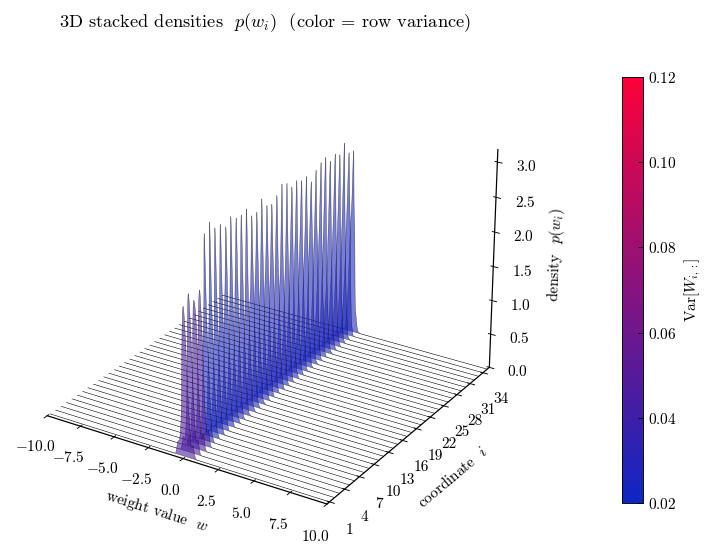

In [ ]:
# === MF snapshot: WW^T heatmap + 3D ridgeline for p(w_i) (boxed look, custom hex gradient, vmin/vmax) ===
import os, sys, glob, math
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------------------------------------------------------
# Locate & import slim_plotters.py no matter if it's in plot_utils/ or plots_utils/
# -----------------------------------------------------------------------------
def import_slim_plotters():
    candidates = [
        "/home/goring/mean_field_langevin/plot_utils",
        "/home/goring/mean_field_langevin/plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]
    # 1) Direct file import path
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            import slim_plotters as sp  # noqa
            return sp
    # 2) Package-style imports
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass
    raise ModuleNotFoundError(
        "Could not import slim_plotters. "
        "Make sure slim_plotters.py exists in one of: "
        + ", ".join(candidates)
    )

sp = import_slim_plotters()
apply, color, COLORS, CYCLE = sp.apply, sp.color, sp.COLORS, sp.CYCLE
apply(theme="light", serif=True)  # or theme="dark"

# -----------------------------------------------------------------------------
# Small helpers for a clean, boxed look (no grey panes, no grids)
# -----------------------------------------------------------------------------
def style_axes_box(ax):
    """2D axes: white background, no grid, visible spines."""
    ax.set_facecolor("white")
    ax.grid(False)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color("black")
    ax.tick_params(axis="both", which="both", length=3, width=0.8, colors="black")

def style_3d_axes_box(ax):
    """3D axes: remove pane fills & grid; keep coordinate lines and box."""
    ax.set_facecolor("white")
    ax.grid(False)
    try:
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
    except Exception:
        pass
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        try:
            axis._axinfo["grid"]["linewidth"] = 0.0
            axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        except Exception:
            pass
        try:
            axis.line.set_color("black")
            axis.line.set_linewidth(0.8)
        except Exception:
            pass
    try:
        ax.w_xaxis.set_pane_color((1, 1, 1, 0))
        ax.w_yaxis.set_pane_color((1, 1, 1, 0))
        ax.w_zaxis.set_pane_color((1, 1, 1, 0))
    except Exception:
        pass

# -----------------------------------------------------------------------------
# IO helpers for MF snapshots
# -----------------------------------------------------------------------------
def find_latest_snapshot(model_dir, suffix="__final_particles.pt"):
    files = glob.glob(os.path.join(model_dir, f"*{suffix}"))
    if not files:
        raise FileNotFoundError(f"No *{suffix} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_mf_snapshot_to_dN(path, experiment="all", stride=1, map_location="cpu"):
    """
    Load MF snapshot .pt and return:
      W_dN: (d, N_total), a_N: (N_total,), meta: dict
    - experiment: "all" to concat all E; or an int e to pick a single experiment.
    - stride: subsample along B to thin.
    """
    pkg = torch.load(path, map_location=map_location)
    W = pkg["params"]["W"]    # (E,B,d)
    a = pkg["params"]["a"]    # (E,B,1)
    meta = pkg["meta"]

    if experiment == "all":
        W2 = W[:, ::stride, :]              # (E, B', d)
        a2 = a[:, ::stride, :]              # (E, B', 1)
        E, Bp, d = W2.shape
        Wflat = W2.reshape(E*Bp, d)         # (E*B', d)
        aflat = a2.reshape(E*Bp)            # (E*B',)
    else:
        e = int(experiment)
        Wflat = W[e, ::stride, :]           # (B', d)
        aflat = a[e, ::stride, 0]           # (B',)

    W_dN = Wflat.T.contiguous().float().cpu()   # (d,N)
    a_N  = aflat.contiguous().float().cpu()     # (N,)
    return W_dN, a_N, meta

# -----------------------------------------------------------------------------
# Minimal 1D Gaussian KDE (no SciPy dependency)
# -----------------------------------------------------------------------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).reshape(-1)
    G = np.asarray(grid, dtype=np.float64).reshape(-1)
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if n == 1:
        bw = 1e-3 if bandwidth is None else float(bandwidth)
    else:
        if bandwidth is None:
            std = np.std(x, ddof=1)
            bw = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
        else:
            bw = float(bandwidth)
        bw = max(bw, 1e-12)
    z = (G[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * bw * math.sqrt(2.0 * math.pi))
    return dens

# -----------------------------------------------------------------------------
# Palette → colormap (customizable with hex stops)
# -----------------------------------------------------------------------------
def linear_cmap_from_hex(stops_hex=None, name="custommap"):
    """
    Build a linear segmented colormap from a list of hex color stops.
    - stops_hex: e.g. ['#0066ff', '#ff3366'] or ['#0066ff','#8a3ffc','#ff3366'].
    """
    if stops_hex is None:
        stops_hex = [color("blue"), color("purple"), color("red")]
    return LinearSegmentedColormap.from_list(name, stops_hex, N=256)

# -----------------------------------------------------------------------------
# Styled WW^T heatmap (custom cmap + vmin/vmax + boxed look)
# -----------------------------------------------------------------------------
def plot_WWT_heatmap(
    W_dN,
    *,
    normalize_by_N=True,
    cmap_stops_hex=None,
    vmin=None,
    vmax=None,
    width=5.8,
    aspect=1.0,
    title=r"$WW^\top$ heatmap"
):
    """
    W_dN: (d,N)  -> G = W W^T (optionally / N)
    """
    W_np = W_dN.detach().cpu().numpy()
    d, N = W_np.shape
    G = W_np @ W_np.T
    if normalize_by_N and N > 0:
        G = G / float(N)

    cm = linear_cmap_from_hex(cmap_stops_hex, name="wwtmap")
    vmin_use = np.min(G) if vmin is None else float(vmin)
    vmax_use = np.max(G) if vmax is None else float(vmax)
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12

    fig, ax = plt.subplots(figsize=(width, width / aspect))
    im = ax.imshow(G, cmap=cm, vmin=vmin_use, vmax=vmax_use, origin="upper", interpolation="nearest")
    cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label(r"value")

    ax.set_xlabel("coordinate  $j$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_title(title)

    # Boxed, clean look
    style_axes_box(ax)

    # Integer ticks if d is small
    if d <= 40:
        ticks = np.arange(0, d, max(1, d // 10))
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xticklabels(ticks + 1)
        ax.set_yticklabels(ticks + 1)

    plt.tight_layout()
    plt.show()
    return fig

# -----------------------------------------------------------------------------
# Styled 3D ridgeline for p(w_i) (custom cmap stops + vmin/vmax for variance + boxed look)
# -----------------------------------------------------------------------------
def plot_coordinate_kdes_3d(
    W_dN,
    grid_points=401,
    weight_range=None,
    bandwidth=None,
    normalize_rows=False,   # keep absolute heights to reflect variance
    y_step=0.85,
    alpha=0.85,
    elev=26,
    azim=-58,
    row_stride=1,           # >1 to thin if d is large
    max_rows=None,
    cmap_stops_hex=None,    # list of hex colors for gradient (start/stop or start/mid/stop)
    var_vmin=None,          # min variance mapped to colormap (if None, computed)
    var_vmax=None           # max variance mapped to colormap (if None, computed)
):
    W_np = W_dN.detach().cpu().numpy()
    d, N = W_np.shape

    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # symmetric range if not provided
    if weight_range is None:
        abs_vals = np.abs(W_np).ravel()
        if abs_vals.size:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.max() > 0 else 1.0))
        else:
            hi = 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)

    grid = np.linspace(lo, hi, grid_points)

    dens, variances = [], []
    for i in rows:
        di = gaussian_kde_1d(W_np[i, :], grid, bandwidth=bandwidth)
        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m
        dens.append(di)
        variances.append(np.var(W_np[i, :], ddof=1))
    dens = np.asarray(dens)
    variances = np.asarray(variances)

    # color by variance using your custom palette
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="varmap")
    vmin_auto, vmax_auto = float(np.min(variances)), float(np.max(variances))
    vmin_use = vmin_auto if var_vmin is None else float(var_vmin)
    vmax_use = vmax_auto if var_vmax is None else float(var_vmax)
    if not np.isfinite(vmin_use): vmin_use = vmin_auto
    if not np.isfinite(vmax_use): vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)

    verts, facecols = [], []
    for di, v in zip(dens, variances):
        poly = list(zip(grid, di)) + [(grid[-1], 0.0), (grid[0], 0.0)]
        verts.append(poly)
        facecols.append(cmap(norm(v)))

    polycoll = PolyCollection(
        verts, facecolors=facecols, edgecolors="black", linewidths=0.3, alpha=alpha
    )

    fig = plt.figure(figsize=(10.0, 6.0))
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection='3d')
    ys = np.arange(len(rows)) * y_step
    ax.add_collection3d(polycoll, zs=ys, zdir='y')

    # limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5 if len(ys) else y_step)
    zmax = float(np.max(dens)) if dens.size else 1.0
    ax.set_zlim(0.0, zmax * 1.05)

    # labels/ticks
    ax.set_xlabel("weight value  $w$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_zlabel(r"density  $p(w_i)$")
    if len(rows):
        tick_every = max(1, len(rows)//10)
        tick_idx = np.arange(0, len(rows), tick_every)
        ax.set_yticks(ys[tick_idx])
        ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])
    ax.view_init(elev=elev, azim=azim)

    # variance colorbar
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.025)
    cbar.set_label(r"$\mathrm{Var}[W_{i,:}]$")

    # Clean boxed style
    style_3d_axes_box(ax)

    #ax.set_title("3D stacked densities  $p(w_i)$  (color = row variance)")
    plt.tight_layout()
    fig.savefig("/home/goring/mean_field_langevin/plots/plots/_pw_MF.svg", bbox_inches="tight")

    plt.show()
    
    return fig

# -----------------------------------------------------------------------------
# Usage
# -----------------------------------------------------------------------------
# Option A: direct snapshot file (init or final)
SNAPSHOT_FILE = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__final_particles.pt"

# Option B: newest *__final_particles.pt in a directory
# SNAPSHOT_DIR = "/home/goring/mean_field_langevin/MCMC_composite/some_results_dir"
# SNAPSHOT_FILE = find_latest_snapshot(SNAPSHOT_DIR, suffix="__final_particles.pt")

print("Loading MF snapshot:", SNAPSHOT_FILE)
W_dN, a_N, meta = load_mf_snapshot_to_dN(SNAPSHOT_FILE, experiment="all", stride=1)
print("W_dN shape (d,N):", tuple(W_dN.shape))

# ---- Customize your colors & ranges here ----
CMAP_STOPS = ["#0E26C4","#FD0139"]       # or e.g. ["#0066ff", "#8a3ffc", "#ff3366"]

# Heatmap value range (colorbar); set to None to auto scale
HEAT_VMIN = 0.12
HEAT_VMAX = 0.02
VAR_VMIN = 0.01                       # row-variance → color mapping (auto if None)
VAR_VMAX = 0.15

# 1) WW^T heatmap (normalized by N)
#_ = plot_WWT_heatmap(
#    W_dN,
#    normalize_by_N=True,
#    cmap_stops_hex=CMAP_STOPS,
#    vmin=HEAT_VMIN,
#    vmax=HEAT_VMAX,
#    width=5.8,
#    aspect=1.0,
#    title=r"$\frac{1}{N}WW^\top$ heatmap"
#)

# 2) 3D ridgeline for p(w_i)
_ = plot_coordinate_kdes_3d(
    W_dN,
    grid_points=1000,
    weight_range=(-2, 2),     # set fixed range (or None for auto)
    bandwidth=None,           # Scott's rule per row
    normalize_rows=False,     # keep absolute heights to reflect variance
    y_step=0.85,
    alpha=0.59,
    elev=26,
    azim=-58,
    row_stride=1,             # use 2/3/... to thin if d is large
    max_rows=None,
    cmap_stops_hex=CMAP_STOPS,
    var_vmin=VAR_VMIN,
    var_vmax=VAR_VMAX
)


In [2]:
# === MF snapshot: p(~m) overlay (two models) in slim style ===
import os, sys, glob, math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ----------------------------------------------------------------------------- #
# robust import of your slim_plotters.py
# ----------------------------------------------------------------------------- #
def import_slim_plotters():
    candidates = [
        "/home/goring/mean_field_langevin/plot_utils",
        "/home/goring/mean_field_langevin/plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            import slim_plotters as sp
            return sp
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass
    raise ModuleNotFoundError("slim_plotters.py not found — update candidate paths above.")

sp = import_slim_plotters()
apply, color, COLORS = sp.apply, sp.color, sp.COLORS
apply(theme="light", serif=True)  # or theme="dark"

# ----------------------------------------------------------------------------- #
# IO helpers for MF snapshots
# ----------------------------------------------------------------------------- #
def find_latest_snapshot(model_dir, suffix="__final_particles.pt"):
    files = glob.glob(os.path.join(model_dir, f"*{suffix}"))
    if not files:
        raise FileNotFoundError(f"No *{suffix} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_mf_snapshot_to_dN(path, experiment="all", stride=1, map_location="cpu"):
    """
    Load MF snapshot .pt saved by the trainer and return:
      W_dN: (d, N_total), a_N: (N_total,), act: str, scale_f: float, meta: dict
    - experiment: "all" to concatenate all E experiments; or an int e to pick one.
    - stride: subsample along particle axis B to thin.
    """
    pkg = torch.load(path, map_location=map_location)
    W = pkg["params"]["W"]    # (E,B,d)
    a = pkg["params"]["a"]    # (E,B,1)
    meta = pkg["meta"]
    act = meta["model"]["act"]
    scale_f = float(meta["scale_f"])

    if experiment == "all":
        W2 = W[:, ::stride, :]              # (E, B', d)
        a2 = a[:, ::stride, :]              # (E, B', 1)
        E, Bp, d = W2.shape
        Wflat = W2.reshape(E*Bp, d)         # (E*B', d)
        aflat = a2.reshape(E*Bp)            # (E*B',)
    else:
        e = int(experiment)
        Wflat = W[e, ::stride, :]           # (B', d)
        aflat = a[e, ::stride, 0]           # (B',)

    # convert to (d,N) and (N,)
    W_dN = Wflat.T.contiguous().float().cpu()
    a_N  = aflat.contiguous().float().cpu()
    return W_dN, a_N, act, scale_f, meta

# ----------------------------------------------------------------------------- #
# Monte Carlo estimator for J_S(w) respecting MF activation
# W_dN: (d,N), returns JS: (N,)
# ----------------------------------------------------------------------------- #
@torch.no_grad()
def estimate_JS_for_all_neurons_MF(W_dN, act="relu", S=(0,1,2,3),
                                   num_samples=200_000, batch_size=100_000,
                                   device=None, seed=123):
    d, N = W_dN.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(int(seed))
    Wd = W_dN.to(device, non_blocking=True)  # (d,N)
    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0

    B, P = int(batch_size), int(num_samples)
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0  # (b,d)
        chi = X[:, list(S)].prod(dim=1, keepdim=True) if len(S)>0 else torch.ones(b,1,device=device)
        Z = X @ Wd                                              # (b,N)
        if act == "relu":
            Phi = F.relu(Z)
        elif act == "tanh":
            Phi = torch.tanh(Z)
        else:
            raise ValueError(f"Unsupported activation for JS: {act}")
        accum += (Phi * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

# ----------------------------------------------------------------------------- #
# Simple Gaussian KDE (no SciPy), identical to your previous
# ----------------------------------------------------------------------------- #
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).ravel()
    G = np.asarray(grid, dtype=np.float64).ravel()
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if bandwidth is None:
        std = np.std(x, ddof=1)
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h = max(float(bandwidth), 1e-12)
    z = (G[:, None] - x[None, :]) / h
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * h * math.sqrt(2.0 * math.pi))
    return dens

# ----------------------------------------------------------------------------- #
# Two-model overlay (unchanged visual style; multiplies inside)
# ----------------------------------------------------------------------------- #
def plot_mtilde_distribution_two_models(
    a1, JS1, a2, JS2, *,
    grid_points=801,
    weight_range=None,         # (lo, hi) or None (auto from both)
    color_hex1="#8710FF",      # color for model 1
    color_hex2="#01B5EB",      # color for model 2
    alpha1=1.0, alpha2=0.55,   # opacity only
    linewidth=2.0,
    fill_alpha_scale=0.25,     # fill alpha = alpha*fill_alpha_scale
    density_floor=1e-12,
    label1="run 1", label2="run 2",
    width=4.6, aspect=1.35,
    x_range=None, y_range=None
):
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    m1 = a1.detach().cpu().numpy().ravel() * JS1.detach().cpu().numpy().ravel()
    m2 = a2.detach().cpu().numpy().ravel() * JS2.detach().cpu().numpy().ravel()

    if weight_range is None:
        all_abs = np.abs(np.concatenate([m1, m2])) if (m1.size and m2.size) else np.abs(m1 if m1.size else m2)
        hi = float(np.quantile(all_abs, 0.995)) if all_abs.size else 1.0
        if not np.isfinite(hi) or hi <= 0:
            hi = max(1.0, float(all_abs.max() if all_abs.size else 1.0))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    p1 = np.clip(gaussian_kde_1d(m1, grid), density_floor, None)
    p2 = np.clip(gaussian_kde_1d(m2, grid), density_floor, None)

    fig, ax = plt.subplots(figsize=(width, width / aspect))
    # curves + fill
    ax.semilogy(grid, p1, color=color_hex1, lw=linewidth, alpha=alpha1, label=label1)
    ax.fill_between(grid, p1, density_floor, color=color_hex1, alpha=alpha1*fill_alpha_scale, linewidth=0)

    ax.semilogy(grid, p2, color=color_hex2, lw=linewidth, alpha=alpha2, label=label2)
    ax.fill_between(grid, p2, density_floor, color=color_hex2, alpha=alpha2*fill_alpha_scale, linewidth=0)

    # labels & legend
    ax.set_title("")
    ax.set_xlabel(r"value of $\tilde m$")
    ax.set_ylabel("")
    ax.legend(frameon=False, loc="upper right")

    # ---- MINOR TICKS: only bottom & left ----
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()
    fig.savefig("/home/goring/mean_field_langevin/plots/plots/m_MF.svg", bbox_inches="tight")

    return fig

# ----------------------------------------------------------------------------- #
# === Usage with MF snapshots ===
# ----------------------------------------------------------------------------- #
# Option A: point directly to two snapshot files
SNAP_A = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P500_kap5.000e-03_Ptr500_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__init_particles.pt"
SNAP_B = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__final_particles.pt"

# Option B: or find the latest final snapshot under two result dirs
# SNAP_A = find_latest_snapshot("/home/goring/mean_field_langevin/MCMC_composite/results_runA")
# SNAP_B = find_latest_snapshot("/home/goring/mean_field_langevin/MCMC_composite/results_runB")

print("Loading MF snapshot A:", SNAP_A)
WA_dN, aA, actA, scaleA, metaA = load_mf_snapshot_to_dN(SNAP_A, experiment="all", stride=1)
print("Loading MF snapshot B:", SNAP_B)
WB_dN, aB, actB, scaleB, metaB = load_mf_snapshot_to_dN(SNAP_B, experiment="all", stride=1)

# Estimate J_S(w) for both (respect their activations)
S = (0,1,2,3)
device = "cuda" if torch.cuda.is_available() else "cpu"
JS_A = estimate_JS_for_all_neurons_MF(WA_dN, act=actA, S=S,
                                      num_samples=100_000, batch_size=20_000,
                                      device=device, seed=123)
JS_B = estimate_JS_for_all_neurons_MF(WB_dN, act=actB, S=S,
                                      num_samples=100_000, batch_size=20_000,
                                      device=device, seed=124)

# IMPORTANT for MF: multiply a by scale_f so m~ = (scale_f * a) * J_S(w)
aA_scaled = aA * float(scaleA)
aB_scaled = aB * float(scaleB)

_ = plot_mtilde_distribution_two_models(
    aA_scaled, JS_A, aB_scaled, JS_B,
    grid_points=18001,
    weight_range=(-15.5, 15.5),   # or None
    color_hex1="#39FD01",          # purple for run 1
    color_hex2="#95A5A6",         # blue for run 2
    alpha1=1.0, alpha2=0.55,
    linewidth=2.0,
    fill_alpha_scale=0.25,
    density_floor=1e-4,
    label1="P=100", label2="P=10000",
    width=3, aspect=1.45,
    x_range=(-0.1, 0.1),             # or None
    y_range=None
)


ImportError: cannot import name 'broadcast_to' from 'numpy.lib.stride_tricks' (/home/goring/miniconda3/envs/env_jax_new/lib/python3.9/site-packages/numpy/lib/stride_tricks.py)

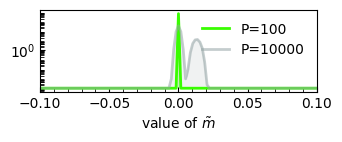

In [3]:
# -*- coding: utf-8 -*-
"""
Overlay p(~m) for TWO MF snapshots, but (like your plot1) show the
across-experiment mean density and a ±k·std band.

Each snapshot is assumed to contain E parallel experiments (shape (E,B,⋯)).
We compute \tilde m = (scale_f * a) * J_S(w) for each experiment e, build a KDE
per experiment, then aggregate them with a weighted mean (weights ∝ #particles
per experiment after any stride) and an across-experiment std.

If a snapshot does not actually contain multiple experiments (e.g. saved with
experiments collapsed), we raise a descriptive error so you can fix the save.
"""

import os, sys, math, glob
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -------------------- (optional) slim theme if you have it --------------------
def _maybe_apply_slim(theme="light", serif=True):
    try:
        candidates = [
            "/home/goring/mean_field_langevin/plot_utils",
            "/home/goring/mean_field_langevin/plots_utils",
            os.path.join(os.getcwd(), "plot_utils"),
            os.path.join(os.getcwd(), "plots_utils"),
        ]
        for d in candidates:
            if os.path.isfile(os.path.join(d, "slim_plotters.py")):
                if d not in sys.path:
                    sys.path.insert(0, d)
                import slim_plotters as sp
                sp.apply(theme=theme, serif=serif)
                return
    except Exception:
        pass

# _maybe_apply_slim(theme="light", serif=True)

# ---------------------------- MF helpers (from plot2) -------------------------
@torch.no_grad()
def estimate_JS_for_all_neurons_MF(W_dN, act="relu", S=(0,1,2,3),
                                   num_samples=200_000, batch_size=100_000,
                                   device=None, seed=123):
    d, N = W_dN.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(int(seed))
    Wd = W_dN.to(device, non_blocking=True)  # (d,N)
    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0

    B, P = int(batch_size), int(num_samples)
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0
        chi = X[:, list(S)].prod(dim=1, keepdim=True) if len(S)>0 else torch.ones(b,1,device=device)
        Z = X @ Wd                                              # (b,N)
        if act == "relu":
            Phi = F.relu(Z)
        elif act == "tanh":
            Phi = torch.tanh(Z)
        else:
            raise ValueError(f"Unsupported activation for JS: {act}")
        accum += (Phi * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

# ----------------------------- simple 1D KDE ---------------------------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).ravel()
    G = np.asarray(grid, dtype=np.float64).ravel()
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if bandwidth is None:
        std = np.std(x, ddof=1) if n > 1 else 0.0
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h = max(float(bandwidth), 1e-12)
    z = (G[:, None] - x[None, :]) / h
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * h * math.sqrt(2.0 * math.pi))
    return dens

# --------------------------- aggregation utils -------------------------------
def _weighted_mean_std(arr_stack, weights=None):
    """arr_stack: shape (M, G). weights: (M,) or None -> equal.
    Returns mean[G], std[G] (population-style)."""
    arr = np.asarray(arr_stack, float)
    if arr.size == 0:
        return np.array([]), np.array([])
    M, G = arr.shape
    if weights is None:
        w = np.ones(M, dtype=float)
    else:
        w = np.asarray(weights, float)
        if w.ndim != 1 or w.size != M:
            raise ValueError("weights must be a 1D array of length #experiments")
    wsum = np.sum(w)
    if not np.isfinite(wsum) or wsum <= 0:
        w = np.ones(M, float); wsum = float(M)
    w = w / wsum
    mean = (w[:, None] * arr).sum(axis=0)
    var = (w[:, None] * (arr - mean)**2).sum(axis=0)
    std = np.sqrt(np.maximum(var, 0.0))
    return mean, std

def kde_aggregate(m_list, grid, *, mode="mixture", bandwidth=None,
                  weights="auto", density_floor=1e-12, return_all=False):
    """
    mode='mixture': average per-experiment KDEs (mean-of-distributions). Provides mean & std.
    mode='pool'   : one KDE on concatenated samples (no across-exp std).
    weights='auto' -> weights ∝ len(m) for each experiment (mixture only).
    """
    if mode not in ("mixture", "pool"):
        raise ValueError("mode must be 'mixture' or 'pool'")
    if mode == "pool":
        pooled = np.concatenate(m_list) if len(m_list) else np.array([])
        d = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        d = np.clip(d, density_floor, None)
        return (d, None) if not return_all else (d, None, None)
    # mixture over experiments
    per = []
    for m in m_list:
        di = gaussian_kde_1d(m, grid, bandwidth=bandwidth)
        per.append(np.clip(di, density_floor, None))
    per = np.asarray(per)
    if weights == "auto":
        w = np.array([len(m) for m in m_list], dtype=float)
    else:
        w = np.asarray(weights) if weights is not None else None
    mean, std = _weighted_mean_std(per, w)
    return (mean, std) if not return_all else (mean, std, per)

# ---------------------- snapshot loading (per experiment) ---------------------

def _load_snapshot_raw(path, map_location="cpu"):
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Snapshot not found: {path}")
    pkg = torch.load(path, map_location=map_location)
    if "params" not in pkg or "meta" not in pkg:
        raise ValueError(f"Snapshot missing keys 'params'/'meta': {path}")
    W = pkg["params"].get("W", None)
    a = pkg["params"].get("a", None)
    if W is None or a is None:
        raise ValueError("Snapshot 'params' must include tensors 'W' and 'a'.")
    if W.ndim != 3 or a.ndim != 3 or a.shape[2] != 1:
        raise ValueError(
            f"Expected W:(E,B,d) and a:(E,B,1). Got W:{tuple(W.shape)} a:{tuple(a.shape)}.\n"
            "This often means the experiments were saved incorrectly or flattened."
        )
    meta = pkg["meta"]
    act = meta.get("model", {}).get("act", None)
    scale_f = float(meta.get("scale_f", 1.0))
    E_meta = int(meta.get("E", W.shape[0]))
    if W.shape[0] != E_meta:
        raise ValueError(
            f"Mismatch: tensor E={W.shape[0]} but meta['E']={E_meta}. Snapshot may be inconsistent."
        )
    return W.cpu().float(), a.cpu().float(), act, scale_f, meta

@torch.no_grad()
def load_experiments_dN(path, *, stride=1, map_location="cpu"):
    """Return a list of (W_dN, a_N) for each experiment e.
    - W_dN has shape (d, N_e), a_N has shape (N_e,)
    """
    W, a, act, scale_f, meta = _load_snapshot_raw(path, map_location)
    E, B, d = W.shape
    exps = []
    for e in range(E):
        Wflat = W[e, ::stride, :]           # (B', d)
        aflat = a[e, ::stride, 0]           # (B',)
        W_dN = Wflat.T.contiguous().float().cpu()
        a_N  = aflat.contiguous().float().cpu()
        exps.append((W_dN, a_N))
    return exps, act, scale_f, meta

# --------------------- compute m~ lists per snapshot --------------------------

def mtilde_per_experiment_from_snapshot(snapshot_path, S=(0,1,2,3), *,
                                        num_samples=200_000, batch_size=100_000,
                                        device=None, seed=123, seed_step=7,
                                        stride=1):
    """Compute a list of 1D numpy arrays of \tilde m for EACH experiment in a snapshot.
       Uses MF scaling: m~ = (scale_f * a) * J_S(w).
    """
    exps, act, scale_f, meta = load_experiments_dN(snapshot_path, stride=stride)
    if act is None:
        raise ValueError("Activation kind not found in snapshot meta['model']['act'].")
    m_list = []
    for k, (W_dN, a_N) in enumerate(exps):
        JS = estimate_JS_for_all_neurons_MF(
            W_dN, act=act, S=S, num_samples=num_samples, batch_size=batch_size,
            device=device, seed=seed + k*seed_step
        )
        mtilde = (a_N.view(-1).cpu().numpy() * float(scale_f)) * (JS.view(-1).cpu().numpy())
        m_list.append(mtilde)
    return m_list, act, scale_f, meta

# ------------------------------ plotting -------------------------------------

def plot_mtilde_two_models_avg_over_experiments(
    snapshot_A, snapshot_B, *,
    S=(0,1,2,3),
    # Monte Carlo
    num_samples=100_000, batch_size=20_000, device=None, seed_A=123, seed_B=456,
    # KDE & aggregation
    avg_mode="mixture",            # 'mixture' (mean of dists) | 'pool' (concatenate)
    bandwidth=None,                # fixed bw; None -> Scott per-KDE
    show_band=True, band_k=1.0,    # fill ± k*std in 'mixture' mode
    # Styling
    grid_points=18001, weight_range=None,
    color_A="#39FD01", color_B="#95A5A6",
    alpha_A=1.0, alpha_B=0.55,
    linewidth=2.0, fill_alpha_scale=0.25,
    density_floor=1e-6,
    label_A="model A (avg)", label_B="model B (avg)",
    width=3.2, aspect=1.45,
    x_range=None, y_range=None,
    savepath=None,
    stride=1
):
    """
    Average p(~m) over experiments inside each snapshot and overlay the two models.
    Shows an across-experiment band if 'mixture' and multiple experiments exist.
    """
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    # --- compute per-experiment \tilde m ---
    mA, actA, scaleA, metaA = mtilde_per_experiment_from_snapshot(
        snapshot_A, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_A, stride=stride
    )
    mB, actB, scaleB, metaB = mtilde_per_experiment_from_snapshot(
        snapshot_B, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_B, stride=stride
    )

    EA = len(mA); EB = len(mB)
    if EA < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_A has E={EA} experiment(s); std band disabled.")
    if EB < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_B has E={EB} experiment(s); std band disabled.")

    # --- grid range from both sets ---
    def _concat_all(ll):
        return np.concatenate(ll) if ll else np.array([])
    all_abs = np.abs(np.concatenate([_concat_all(mA), _concat_all(mB)]))
    if weight_range is None:
        hi = float(np.quantile(all_abs, 0.995)) if all_abs.size else 1.0
        if not np.isfinite(hi) or hi <= 0:
            hi = max(1.0, float(all_abs.max() if all_abs.size else 1.0))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, int(grid_points))

    # --- aggregate KDEs for both models (over experiments) ---
    dA, sA = kde_aggregate(mA, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)
    dB, sB = kde_aggregate(mB, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(width, width / aspect))

    ax.semilogy(grid, dA, color=color_A, lw=linewidth, alpha=alpha_A, label=label_A)
    ax.fill_between(grid, dA, density_floor, color=color_A,
                    alpha=alpha_A*fill_alpha_scale, linewidth=0)
    if show_band and (sA is not None) and np.any(sA > 0):
        loA = np.clip(dA - band_k*sA, density_floor, None)
        hiA = np.clip(dA + band_k*sA, density_floor, None)
        ax.fill_between(grid, loA, hiA, color=color_A, alpha=0.18, linewidth=0)

    ax.semilogy(grid, dB, color=color_B, lw=linewidth, alpha=alpha_B, label=label_B)
    ax.fill_between(grid, dB, density_floor, color=color_B,
                    alpha=alpha_B*fill_alpha_scale, linewidth=0)
    if show_band and (sB is not None) and np.any(sB > 0):
        loB = np.clip(dB - band_k*sB, density_floor, None)
        hiB = np.clip(dB + band_k*sB, density_floor, None)
        ax.fill_between(grid, loB, hiB, color=color_B, alpha=0.18, linewidth=0)

    ax.set_xlabel(r"value of $\tilde m$")
    ax.legend(frameon=False, loc="upper right")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()

    if savepath is not None:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(savepath, bbox_inches="tight")

    return fig, {
        "grid": grid,
        "density_A": dA,
        "std_A": sA,
        "density_B": dB,
        "std_B": sB,
        "meta_A": metaA,
        "meta_B": metaB,
    }

# ------------------------------- example usage -------------------------------
if __name__ == "__main__":
    # Point these to your snapshot files (same as in your plot2 script)
    SNAP_A = \
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/" \
        "rs_aw_ard_sgld_FAST_P500_kap5.000e-03_Ptr500_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__init_particles.pt"
    SNAP_B = \
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/" \
        "rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__final_particles.pt"

    # S = (0,1,2,3)
    S = (0,1,2,3)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    plot_mtilde_two_models_avg_over_experiments(
        SNAP_A, SNAP_B,
        S=S,
        num_samples=100_000, batch_size=20_000, device=device,
        avg_mode="mixture", bandwidth=None, show_band=True, band_k=1.0,
        grid_points=18001, weight_range=(-15.5, 15.5),
        color_A="#39FD01", color_B="#95A5A6",
        alpha_A=1.0, alpha_B=0.55, linewidth=2.0, fill_alpha_scale=0.25,
        density_floor=1e-4,
        label_A="P=100", label_B="P=10000",
        width=3.6, aspect=2.3,
        x_range=(-0.1, 0.1), y_range=None,
        savepath="/home/goring/mean_field_langevin/plots/plots/m_MF_avg_over_E.svg",
        stride=1,
    )






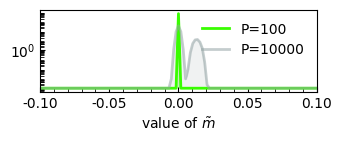

In [7]:
# -*- coding: utf-8 -*-
"""
Overlay p(~m) for TWO MF snapshots, but (like your plot1) show the
across-experiment mean density and a ±k·std band.

Each snapshot is assumed to contain E parallel experiments (shape (E,B,⋯)).
We compute \tilde m = (scale_f * a) * J_S(w) for each experiment e, build a KDE
per experiment, then aggregate them with a weighted mean (weights ∝ #particles
per experiment after any stride) and an across-experiment std.

If a snapshot does not actually contain multiple experiments (e.g. saved with
experiments collapsed), we raise a descriptive error so you can fix the save.
"""

import os, sys, math, glob
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt

# ============================== FONT CONSISTENCY ==============================
# Force a consistent font across runs (to match code2 defaults).
# Change to "serif" if you want serif everywhere, and we’ll also sync mathtext.
FORCE_FONT_FAMILY = "sans"   # "sans" or "serif"

def _force_matplotlib_fonts(family="sans"):
    fam_is_sans = (str(family).lower() == "sans")
    mpl.rcParams.update({
        "text.usetex": False,  # keep Matplotlib mathtext (portable)
        "font.family": "sans-serif" if fam_is_sans else "serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "CMU Serif"],
        "mathtext.fontset": "dejavusans" if fam_is_sans else "dejavuserif",
        "axes.unicode_minus": False,
        # Keep text as text in SVGs and modern embedding for PDF/PS
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

_force_matplotlib_fonts(FORCE_FONT_FAMILY)

# -------------------- (optional) slim theme if you have it --------------------
def _maybe_apply_slim(theme="light", serif=(FORCE_FONT_FAMILY=="serif")):
    """
    Optional: apply your slim_plotters theme IF present.
    We re-apply our font override afterward to keep fonts consistent.
    """
    try:
        candidates = [
            "/home/goring/mean_field_langevin/plot_utils",
            "/home/goring/mean_field_langevin/plots_utils",
            os.path.join(os.getcwd(), "plot_utils"),
            os.path.join(os.getcwd(), "plots_utils"),
        ]
        for d in candidates:
            if os.path.isfile(os.path.join(d, "slim_plotters.py")):
                if d not in sys.path:
                    sys.path.insert(0, d)
                import slim_plotters as sp
                sp.apply(theme=theme, serif=serif)
                _force_matplotlib_fonts("serif" if serif else "sans")  # keep our font choice
                return
    except Exception:
        pass

# If you want the slim theme AND the same font family, uncomment:
# _maybe_apply_slim(theme="light", serif=(FORCE_FONT_FAMILY=="serif"))

# ---------------------------- MF helpers (from plot2) -------------------------
@torch.no_grad()
def estimate_JS_for_all_neurons_MF(W_dN, act="relu", S=(0,1,2,3),
                                   num_samples=200_000, batch_size=100_000,
                                   device=None, seed=123):
    d, N = W_dN.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(int(seed))
    Wd = W_dN.to(device, non_blocking=True)  # (d,N)
    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0

    B, P = int(batch_size), int(num_samples)
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0
        chi = X[:, list(S)].prod(dim=1, keepdim=True) if len(S)>0 else torch.ones(b,1,device=device)
        Z = X @ Wd                                              # (b,N)
        if act == "relu":
            Phi = F.relu(Z)
        elif act == "tanh":
            Phi = torch.tanh(Z)
        else:
            raise ValueError(f"Unsupported activation for JS: {act}")
        accum += (Phi * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

# ----------------------------- simple 1D KDE ---------------------------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).ravel()
    G = np.asarray(grid, dtype=np.float64).ravel()
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if bandwidth is None:
        std = np.std(x, ddof=1) if n > 1 else 0.0
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h = max(float(bandwidth), 1e-12)
    z = (G[:, None] - x[None, :]) / h
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * h * math.sqrt(2.0 * math.pi))
    return dens

# --------------------------- aggregation utils -------------------------------
def _weighted_mean_std(arr_stack, weights=None):
    """arr_stack: shape (M, G). weights: (M,) or None -> equal.
    Returns mean[G], std[G] (population-style)."""
    arr = np.asarray(arr_stack, float)
    if arr.size == 0:
        return np.array([]), np.array([])
    M, G = arr.shape
    if weights is None:
        w = np.ones(M, dtype=float)
    else:
        w = np.asarray(weights, float)
        if w.ndim != 1 or w.size != M:
            raise ValueError("weights must be a 1D array of length #experiments")
    wsum = np.sum(w)
    if not np.isfinite(wsum) or wsum <= 0:
        w = np.ones(M, float); wsum = float(M)
    w = w / wsum
    mean = (w[:, None] * arr).sum(axis=0)
    var = (w[:, None] * (arr - mean)**2).sum(axis=0)
    std = np.sqrt(np.maximum(var, 0.0))
    return mean, std

def kde_aggregate(m_list, grid, *, mode="mixture", bandwidth=None,
                  weights="auto", density_floor=1e-12, return_all=False):
    """
    mode='mixture': average per-experiment KDEs (mean-of-distributions). Provides mean & std.
    mode='pool'   : one KDE on concatenated samples (no across-exp std).
    weights='auto' -> weights ∝ len(m) for each experiment (mixture only).
    """
    if mode not in ("mixture", "pool"):
        raise ValueError("mode must be 'mixture' or 'pool'")
    if mode == "pool":
        pooled = np.concatenate(m_list) if len(m_list) else np.array([])
        d = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        d = np.clip(d, density_floor, None)
        return (d, None) if not return_all else (d, None, None)
    # mixture over experiments
    per = []
    for m in m_list:
        di = gaussian_kde_1d(m, grid, bandwidth=bandwidth)
        per.append(np.clip(di, density_floor, None))
    per = np.asarray(per)
    if weights == "auto":
        w = np.array([len(m) for m in m_list], dtype=float)
    else:
        w = np.asarray(weights) if weights is not None else None
    mean, std = _weighted_mean_std(per, w)
    return (mean, std) if not return_all else (mean, std, per)

# ---------------------- snapshot loading (per experiment) ---------------------

def _load_snapshot_raw(path, map_location="cpu"):
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Snapshot not found: {path}")
    pkg = torch.load(path, map_location=map_location)
    if "params" not in pkg or "meta" not in pkg:
        raise ValueError(f"Snapshot missing keys 'params'/'meta': {path}")
    W = pkg["params"].get("W", None)
    a = pkg["params"].get("a", None)
    if W is None or a is None:
        raise ValueError("Snapshot 'params' must include tensors 'W' and 'a'.")
    if W.ndim != 3 or a.ndim != 3 or a.shape[2] != 1:
        raise ValueError(
            f"Expected W:(E,B,d) and a:(E,B,1). Got W:{tuple(W.shape)} a:{tuple(a.shape)}.\n"
            "This often means the experiments were saved incorrectly or flattened."
        )
    meta = pkg["meta"]
    act = meta.get("model", {}).get("act", None)
    scale_f = float(meta.get("scale_f", 1.0))
    E_meta = int(meta.get("E", W.shape[0]))
    if W.shape[0] != E_meta:
        raise ValueError(
            f"Mismatch: tensor E={W.shape[0]} but meta['E']={E_meta}. Snapshot may be inconsistent."
        )
    return W.cpu().float(), a.cpu().float(), act, scale_f, meta

@torch.no_grad()
def load_experiments_dN(path, *, stride=1, map_location="cpu"):
    """Return a list of (W_dN, a_N) for each experiment e.
    - W_dN has shape (d, N_e), a_N has shape (N_e,)
    """
    W, a, act, scale_f, meta = _load_snapshot_raw(path, map_location)
    E, B, d = W.shape
    exps = []
    for e in range(E):
        Wflat = W[e, ::stride, :]           # (B', d)
        aflat = a[e, ::stride, 0]           # (B',)
        W_dN = Wflat.T.contiguous().float().cpu()
        a_N  = aflat.contiguous().float().cpu()
        exps.append((W_dN, a_N))
    return exps, act, scale_f, meta

# --------------------- compute m~ lists per snapshot --------------------------
@torch.no_grad()
def mtilde_per_experiment_from_snapshot(snapshot_path, S=(0,1,2,3), *,
                                        num_samples=200_000, batch_size=100_000,
                                        device=None, seed=123, seed_step=7,
                                        stride=1):
    """Compute a list of 1D numpy arrays of \tilde m for EACH experiment in a snapshot.
       Uses MF scaling: m~ = (scale_f * a) * J_S(w).
    """
    exps, act, scale_f, meta = load_experiments_dN(snapshot_path, stride=stride)
    if act is None:
        raise ValueError("Activation kind not found in snapshot meta['model']['act'].")

    m_list = []
    for k, (W_dN, a_N) in enumerate(exps):
        JS = estimate_JS_for_all_neurons_MF(
            W_dN, act=act, S=S,
            num_samples=num_samples, batch_size=batch_size,
            device=device, seed=seed + k*seed_step
        )
        a_np  = a_N.view(-1).cpu().numpy()
        js_np = JS.view(-1).cpu().numpy()
        mtilde = (float(scale_f) * a_np) * js_np
        m_list.append(mtilde)

    return m_list, act, scale_f, meta

# ------------------------------ plotting -------------------------------------

def plot_mtilde_two_models_avg_over_experiments(
    snapshot_A, snapshot_B, *,
    S=(0,1,2,3),
    # Monte Carlo
    num_samples=100_000, batch_size=20_000, device=None, seed_A=123, seed_B=456,
    # KDE & aggregation
    avg_mode="mixture",            # 'mixture' (mean of dists) | 'pool' (concatenate)
    bandwidth=None,                # fixed bw; None -> Scott per-KDE
    show_band=True, band_k=1.0,    # fill ± k*std in 'mixture' mode
    # Styling
    grid_points=18001, weight_range=None,
    color_A="#39FD01", color_B="#95A5A6",
    alpha_A=1.0, alpha_B=0.55,
    linewidth=2.0, fill_alpha_scale=0.25,
    density_floor=1e-6,
    label_A="model A (avg)", label_B="model B (avg)",
    width=3.2, aspect=1.45,
    x_range=None, y_range=None,
    savepath=None,
    stride=1
):
    """
    Average p(~m) over experiments inside each snapshot and overlay the two models.
    Shows an across-experiment band if 'mixture' and multiple experiments exist.
    """
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    # --- compute per-experiment \tilde m ---
    mA, actA, scaleA, metaA = mtilde_per_experiment_from_snapshot(
        snapshot_A, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_A, stride=stride
    )
    mB, actB, scaleB, metaB = mtilde_per_experiment_from_snapshot(
        snapshot_B, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_B, stride=stride
    )

    EA = len(mA); EB = len(mB)
    if EA < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_A has E={EA} experiment(s); std band disabled.")
    if EB < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_B has E={EB} experiment(s); std band disabled.")

    # --- grid range from both sets ---
    def _concat_all(ll):
        return np.concatenate(ll) if ll else np.array([])
    all_abs = np.abs(np.concatenate([_concat_all(mA), _concat_all(mB)]))
    if weight_range is None:
        hi = float(np.quantile(all_abs, 0.995)) if all_abs.size else 1.0
        if not np.isfinite(hi) or hi <= 0:
            hi = max(1.0, float(all_abs.max() if all_abs.size else 1.0))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, int(grid_points))

    # --- aggregate KDEs for both models (over experiments) ---
    dA, sA = kde_aggregate(mA, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)
    dB, sB = kde_aggregate(mB, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(width, width / aspect))

    ax.semilogy(grid, dA, color=color_A, lw=linewidth, alpha=alpha_A, label=label_A)
    ax.fill_between(grid, dA, density_floor, color=color_A,
                    alpha=alpha_A*fill_alpha_scale, linewidth=0)
    if show_band and (sA is not None) and np.any(sA > 0):
        loA = np.clip(dA - band_k*sA, density_floor, None)
        hiA = np.clip(dA + band_k*sA, density_floor, None)
        ax.fill_between(grid, loA, hiA, color=color_A, alpha=0.18, linewidth=0)

    ax.semilogy(grid, dB, color=color_B, lw=linewidth, alpha=alpha_B, label=label_B)
    ax.fill_between(grid, dB, density_floor, color=color_B,
                    alpha=alpha_B*fill_alpha_scale, linewidth=0)
    if show_band and (sB is not None) and np.any(sB > 0):
        loB = np.clip(dB - band_k*sB, density_floor, None)
        hiB = np.clip(dB + band_k*sB, density_floor, None)
        ax.fill_between(grid, loB, hiB, color=color_B, alpha=0.18, linewidth=0)

    ax.set_xlabel(r"value of $\tilde m$")
    ax.legend(frameon=False, loc="upper right")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()

    if savepath is not None:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(savepath, bbox_inches="tight")

    return fig, {
        "grid": grid,
        "density_A": dA,
        "std_A": sA,
        "density_B": dB,
        "std_B": sB,
        "meta_A": metaA,
        "meta_B": metaB,
    }

# ------------------------------- example usage -------------------------------
if __name__ == "__main__":
    # Point these to your snapshot files (same as in your plot2 script)
    SNAP_A = \
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/" \
        "rs_aw_ard_sgld_FAST_P500_kap5.000e-03_Ptr500_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__init_particles.pt"
    SNAP_B = \
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/" \
        "rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__final_particles.pt"

    S = (0,1,2,3)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    plot_mtilde_two_models_avg_over_experiments(
        SNAP_A, SNAP_B,
        S=S,
        num_samples=100_000, batch_size=20_000, device=device,
        avg_mode="mixture", bandwidth=None, show_band=True, band_k=1.0,
        grid_points=18001, weight_range=(-15.5, 15.5),
        color_A="#39FD01", color_B="#95A5A6",
        alpha_A=1.0, alpha_B=0.55, linewidth=2.0, fill_alpha_scale=0.25,
        density_floor=1e-4,
        label_A="P=100", label_B="P=10000",
        width=3.6, aspect=2.3,
        x_range=(-0.1, 0.1), y_range=None,
        savepath="/home/goring/mean_field_langevin/plots/plots/m_MF_avg_over_E.svg",
        stride=1,
    )


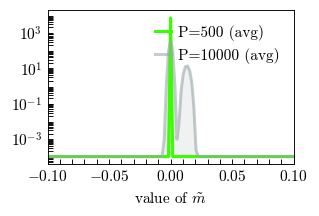

In [23]:
# -*- coding: utf-8 -*-
"""
Overlay p(~m) for TWO MF snapshots, but (like your plot1) show the
across-experiment mean density and a ±k·std band.

Each snapshot is assumed to contain E parallel experiments (shape (E,B,⋯)).
We compute \tilde m = (scale_f * a) * J_S(w) for each experiment e, build a KDE
per experiment, then aggregate them with a weighted mean (weights ∝ #particles
per experiment after any stride) and an across-experiment std.

If a snapshot does not actually contain multiple experiments (e.g. saved with
experiments collapsed), we raise a descriptive error so you can fix the save.
"""

import os, sys, math, glob
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -------------------- (optional) slim theme if you have it --------------------
def _maybe_apply_slim(theme="light", serif=True):
    try:
        candidates = [
            "/home/goring/mean_field_langevin/plot_utils",
            "/home/goring/mean_field_langevin/plots_utils",
            os.path.join(os.getcwd(), "plot_utils"),
            os.path.join(os.getcwd(), "plots_utils"),
        ]
        for d in candidates:
            if os.path.isfile(os.path.join(d, "slim_plotters.py")):
                if d not in sys.path:
                    sys.path.insert(0, d)
                import slim_plotters as sp
                sp.apply(theme=theme, serif=serif)
                return
    except Exception:
        pass

_maybe_apply_slim(theme="light", serif=True)

# ---------------------------- MF helpers (from plot2) -------------------------
@torch.no_grad()
def estimate_JS_for_all_neurons_MF(W_dN, act="relu", S=(0,1,2,3),
                                   num_samples=200_000, batch_size=100_000,
                                   device=None, seed=123):
    d, N = W_dN.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(int(seed))
    Wd = W_dN.to(device, non_blocking=True)  # (d,N)
    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0

    B, P = int(batch_size), int(num_samples)
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0
        chi = X[:, list(S)].prod(dim=1, keepdim=True) if len(S)>0 else torch.ones(b,1,device=device)
        Z = X @ Wd                                              # (b,N)
        if act == "relu":
            Phi = F.relu(Z)
        elif act == "tanh":
            Phi = torch.tanh(Z)
        else:
            raise ValueError(f"Unsupported activation for JS: {act}")
        accum += (Phi * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

# ----------------------------- simple 1D KDE ---------------------------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).ravel()
    G = np.asarray(grid, dtype=np.float64).ravel()
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if bandwidth is None:
        std = np.std(x, ddof=1) if n > 1 else 0.0
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h = max(float(bandwidth), 1e-12)
    z = (G[:, None] - x[None, :]) / h
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * h * math.sqrt(2.0 * math.pi))
    return dens

# --------------------------- aggregation utils -------------------------------
def _weighted_mean_std(arr_stack, weights=None):
    """arr_stack: shape (M, G). weights: (M,) or None -> equal.
    Returns mean[G], std[G] (population-style)."""
    arr = np.asarray(arr_stack, float)
    if arr.size == 0:
        return np.array([]), np.array([])
    M, G = arr.shape
    if weights is None:
        w = np.ones(M, dtype=float)
    else:
        w = np.asarray(weights, float)
        if w.ndim != 1 or w.size != M:
            raise ValueError("weights must be a 1D array of length #experiments")
    wsum = np.sum(w)
    if not np.isfinite(wsum) or wsum <= 0:
        w = np.ones(M, float); wsum = float(M)
    w = w / wsum
    mean = (w[:, None] * arr).sum(axis=0)
    var = (w[:, None] * (arr - mean)**2).sum(axis=0)
    std = np.sqrt(np.maximum(var, 0.0))
    return mean, std

def kde_aggregate(m_list, grid, *, mode="mixture", bandwidth=None,
                  weights="auto", density_floor=1e-12, return_all=False):
    """
    mode='mixture': average per-experiment KDEs (mean-of-distributions). Provides mean & std.
    mode='pool'   : one KDE on concatenated samples (no across-exp std).
    weights='auto' -> weights ∝ len(m) for each experiment (mixture only).
    """
    if mode not in ("mixture", "pool"):
        raise ValueError("mode must be 'mixture' or 'pool'")
    if mode == "pool":
        pooled = np.concatenate(m_list) if len(m_list) else np.array([])
        d = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        d = np.clip(d, density_floor, None)
        return (d, None) if not return_all else (d, None, None)
    # mixture over experiments
    per = []
    for m in m_list:
        di = gaussian_kde_1d(m, grid, bandwidth=bandwidth)
        per.append(np.clip(di, density_floor, None))
    per = np.asarray(per)
    if weights == "auto":
        w = np.array([len(m) for m in m_list], dtype=float)
    else:
        w = np.asarray(weights) if weights is not None else None
    mean, std = _weighted_mean_std(per, w)
    return (mean, std) if not return_all else (mean, std, per)

# ---------------------- snapshot loading (per experiment) ---------------------

def _load_snapshot_raw(path, map_location="cpu"):
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Snapshot not found: {path}")
    pkg = torch.load(path, map_location=map_location)
    if "params" not in pkg or "meta" not in pkg:
        raise ValueError(f"Snapshot missing keys 'params'/'meta': {path}")
    W = pkg["params"].get("W", None)
    a = pkg["params"].get("a", None)
    if W is None or a is None:
        raise ValueError("Snapshot 'params' must include tensors 'W' and 'a'.")
    if W.ndim != 3 or a.ndim != 3 or a.shape[2] != 1:
        raise ValueError(
            f"Expected W:(E,B,d) and a:(E,B,1). Got W:{tuple(W.shape)} a:{tuple(a.shape)}.\n"
            "This often means the experiments were saved incorrectly or flattened."
        )
    meta = pkg["meta"]
    act = meta.get("model", {}).get("act", None)
    scale_f = float(meta.get("scale_f", 1.0))
    E_meta = int(meta.get("E", W.shape[0]))
    if W.shape[0] != E_meta:
        raise ValueError(
            f"Mismatch: tensor E={W.shape[0]} but meta['E']={E_meta}. Snapshot may be inconsistent."
        )
    return W.cpu().float(), a.cpu().float(), act, scale_f, meta

@torch.no_grad()
def load_experiments_dN(path, *, stride=1, map_location="cpu"):
    """Return a list of (W_dN, a_N) for each experiment e.
    - W_dN has shape (d, N_e), a_N has shape (N_e,)
    """
    W, a, act, scale_f, meta = _load_snapshot_raw(path, map_location)
    E, B, d = W.shape
    exps = []
    for e in range(E):
        Wflat = W[e, ::stride, :]           # (B', d)
        aflat = a[e, ::stride, 0]           # (B',)
        W_dN = Wflat.T.contiguous().float().cpu()
        a_N  = aflat.contiguous().float().cpu()
        exps.append((W_dN, a_N))
    return exps, act, scale_f, meta

# --------------------- compute m~ lists per snapshot --------------------------

def mtilde_per_experiment_from_snapshot(snapshot_path, S=(0,1,2,3), *,
                                        num_samples=200_000, batch_size=100_000,
                                        device=None, seed=123, seed_step=7,
                                        stride=1):
    """Compute a list of 1D numpy arrays of \tilde m for EACH experiment in a snapshot.
       Uses MF scaling: m~ = (scale_f * a) * J_S(w).
    """
    exps, act, scale_f, meta = load_experiments_dN(snapshot_path, stride=stride)
    if act is None:
        raise ValueError("Activation kind not found in snapshot meta['model']['act'].")
    m_list = []
    for k, (W_dN, a_N) in enumerate(exps):
        JS = estimate_JS_for_all_neurons_MF(
            W_dN, act=act, S=S, num_samples=num_samples, batch_size=batch_size,
            device=device, seed=seed + k*seed_step
        )
        mtilde = (a_N.view(-1).cpu().numpy() * float(scale_f)) * (JS.view(-1).cpu().numpy())
        m_list.append(mtilde)
    return m_list, act, scale_f, meta

# ------------------------------ plotting -------------------------------------

def plot_mtilde_two_models_avg_over_experiments(
    snapshot_A, snapshot_B, *,
    S=(0,1,2,3),
    # Monte Carlo
    num_samples=100_000, batch_size=20_000, device=None, seed_A=123, seed_B=456,
    # KDE & aggregation
    avg_mode="mixture",            # 'mixture' (mean of dists) | 'pool' (concatenate)
    bandwidth=None,                # fixed bw; None -> Scott per-KDE
    show_band=True, band_k=1.0,    # fill ± k*std in 'mixture' mode
    # Styling
    grid_points=18001, weight_range=None,
    color_A="#39FD01", color_B="#95A5A6",
    alpha_A=1.0, alpha_B=0.55,
    linewidth=2.0, fill_alpha_scale=0.25,
    density_floor=1e-6,
    label_A="model A (avg)", label_B="model B (avg)",
    width=3.2, aspect=1.45,
    x_range=None, y_range=None,
    savepath=None,
    stride=1
):
    """
    Average p(~m) over experiments inside each snapshot and overlay the two models.
    Shows an across-experiment band if 'mixture' and multiple experiments exist.
    """
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    # --- compute per-experiment \tilde m ---
    mA, actA, scaleA, metaA = mtilde_per_experiment_from_snapshot(
        snapshot_A, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_A, stride=stride
    )
    mB, actB, scaleB, metaB = mtilde_per_experiment_from_snapshot(
        snapshot_B, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_B, stride=stride
    )

    EA = len(mA); EB = len(mB)
    if EA < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_A has E={EA} experiment(s); std band disabled.")
    if EB < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_B has E={EB} experiment(s); std band disabled.")

    # --- grid range from both sets ---
    def _concat_all(ll):
        return np.concatenate(ll) if ll else np.array([])
    all_abs = np.abs(np.concatenate([_concat_all(mA), _concat_all(mB)]))
    if weight_range is None:
        hi = float(np.quantile(all_abs, 0.995)) if all_abs.size else 1.0
        if not np.isfinite(hi) or hi <= 0:
            hi = max(1.0, float(all_abs.max() if all_abs.size else 1.0))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, int(grid_points))

    # --- aggregate KDEs for both models (over experiments) ---
    dA, sA = kde_aggregate(mA, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)
    dB, sB = kde_aggregate(mB, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(width, width / aspect))

    ax.semilogy(grid, dA, color=color_A, lw=linewidth, alpha=alpha_A, label=label_A)
    ax.fill_between(grid, dA, density_floor, color=color_A,
                    alpha=alpha_A*fill_alpha_scale, linewidth=0)
    if show_band and (sA is not None) and np.any(sA > 0):
        loA = np.clip(dA - band_k*sA, density_floor, None)
        hiA = np.clip(dA + band_k*sA, density_floor, None)
        ax.fill_between(grid, loA, hiA, color=color_A, alpha=0.18, linewidth=0)

    ax.semilogy(grid, dB, color=color_B, lw=linewidth, alpha=alpha_B, label=label_B)
    ax.fill_between(grid, dB, density_floor, color=color_B,
                    alpha=alpha_B*fill_alpha_scale, linewidth=0)
    if show_band and (sB is not None) and np.any(sB > 0):
        loB = np.clip(dB - band_k*sB, density_floor, None)
        hiB = np.clip(dB + band_k*sB, density_floor, None)
        ax.fill_between(grid, loB, hiB, color=color_B, alpha=0.18, linewidth=0)

    ax.set_xlabel(r"value of $\tilde m$")
    ax.legend(frameon=False, loc="upper right")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()

    if savepath is not None:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(savepath, bbox_inches="tight")

    return fig, {
        "grid": grid,
        "density_A": dA,
        "std_A": sA,
        "density_B": dB,
        "std_B": sB,
        "meta_A": metaA,
        "meta_B": metaB,
    }

# ------------------------------- example usage -------------------------------
if __name__ == "__main__":
    # Point these to your snapshot files (same as in your plot2 script)
    SNAP_A = \
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/" \
        "rs_aw_ard_sgld_FAST_P500_kap5.000e-03_Ptr500_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__init_particles.pt"
    SNAP_B = \
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/" \
        "rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__final_particles.pt"

    # S = (0,1,2,3)
    S = (0,1,2,3)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    plot_mtilde_two_models_avg_over_experiments(
        SNAP_A, SNAP_B,
        S=S,
        num_samples=100_000, batch_size=20_000, device=device,
        avg_mode="mixture", bandwidth=None, show_band=True, band_k=1.0,
        grid_points=18001, weight_range=(-15.5, 15.5),
        color_A="#39FD01", color_B="#95A5A6",
        alpha_A=1.0, alpha_B=0.55, linewidth=2.0, fill_alpha_scale=0.25,
        density_floor=1e-4,
        label_A="P=500 (avg)", label_B="P=10000 (avg)",
        width=3.0, aspect=1.45,
        x_range=(-0.1, 0.1), y_range=None,
        savepath="/home/goring/mean_field_langevin/plots/plots/m_MF_avg_over_E.svg",
        stride=1,
    )


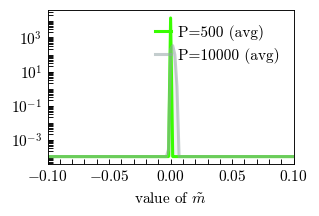

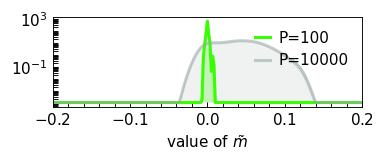

In [5]:
# -*- coding: utf-8 -*-
"""
Overlay p(~m) for TWO MF snapshots, but (like your plot1) show the
across-experiment mean density and a ±k·std band.

Each snapshot is assumed to contain E parallel experiments (shape (E,B,⋯)).
We compute \tilde m = (scale_f * a) * J_S(w) for each experiment e, build a KDE
per experiment, then aggregate them with a weighted mean (weights ∝ #particles
per experiment after any stride) and an across-experiment std.

If a snapshot does not actually contain multiple experiments (e.g. saved with
experiments collapsed), we raise a descriptive error so you can fix the save.
"""

import os, sys, math, glob
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt

# ============================== FONT CONSISTENCY ==============================
# Force a consistent font across runs (to match code2 defaults).
# Change to "serif" if you want serif everywhere, and we’ll also sync mathtext.
FORCE_FONT_FAMILY = "sans"   # "sans" or "serif"

def _force_matplotlib_fonts(family="sans"):
    fam_is_sans = (str(family).lower() == "sans")
    mpl.rcParams.update({
        "text.usetex": False,  # keep Matplotlib mathtext (portable)
        "font.family": "sans-serif" if fam_is_sans else "serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "CMU Serif"],
        "mathtext.fontset": "dejavusans" if fam_is_sans else "dejavuserif",
        "axes.unicode_minus": False,
        # Keep text as text in SVGs and modern embedding for PDF/PS
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

_force_matplotlib_fonts(FORCE_FONT_FAMILY)

# -------------------- (optional) slim theme if you have it --------------------
def _maybe_apply_slim(theme="light", serif=(FORCE_FONT_FAMILY=="serif")):
    """
    Optional: apply your slim_plotters theme IF present.
    We re-apply our font override afterward to keep fonts consistent.
    """
    try:
        candidates = [
            "/home/goring/mean_field_langevin/plot_utils",
            "/home/goring/mean_field_langevin/plots_utils",
            os.path.join(os.getcwd(), "plot_utils"),
            os.path.join(os.getcwd(), "plots_utils"),
        ]
        for d in candidates:
            if os.path.isfile(os.path.join(d, "slim_plotters.py")):
                if d not in sys.path:
                    sys.path.insert(0, d)
                import slim_plotters as sp
                sp.apply(theme=theme, serif=serif)
                _force_matplotlib_fonts("serif" if serif else "sans")  # keep our font choice
                return
    except Exception:
        pass

# If you want the slim theme AND the same font family, uncomment:
_maybe_apply_slim(theme="light", serif=(FORCE_FONT_FAMILY=="serif"))

# ---------------------------- MF helpers (from plot2) -------------------------
@torch.no_grad()
def estimate_JS_for_all_neurons_MF(W_dN, act="relu", S=(0,1,2,3),
                                   num_samples=200_000, batch_size=100_000,
                                   device=None, seed=123):
    d, N = W_dN.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(int(seed))
    Wd = W_dN.to(device, non_blocking=True)  # (d,N)
    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0

    B, P = int(batch_size), int(num_samples)
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0
        chi = X[:, list(S)].prod(dim=1, keepdim=True) if len(S)>0 else torch.ones(b,1,device=device)
        Z = X @ Wd                                              # (b,N)
        if act == "relu":
            Phi = F.relu(Z)
        elif act == "tanh":
            Phi = torch.tanh(Z)
        else:
            raise ValueError(f"Unsupported activation for JS: {act}")
        accum += (Phi * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

# ----------------------------- simple 1D KDE ---------------------------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).ravel()
    G = np.asarray(grid, dtype=np.float64).ravel()
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if bandwidth is None:
        std = np.std(x, ddof=1) if n > 1 else 0.0
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h = max(float(bandwidth), 1e-12)
    z = (G[:, None] - x[None, :]) / h
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * h * math.sqrt(2.0 * math.pi))
    return dens

# --------------------------- aggregation utils -------------------------------
def _weighted_mean_std(arr_stack, weights=None):
    """arr_stack: shape (M, G). weights: (M,) or None -> equal.
    Returns mean[G], std[G] (population-style)."""
    arr = np.asarray(arr_stack, float)
    if arr.size == 0:
        return np.array([]), np.array([])
    M, G = arr.shape
    if weights is None:
        w = np.ones(M, dtype=float)
    else:
        w = np.asarray(weights, float)
        if w.ndim != 1 or w.size != M:
            raise ValueError("weights must be a 1D array of length #experiments")
    wsum = np.sum(w)
    if not np.isfinite(wsum) or wsum <= 0:
        w = np.ones(M, float); wsum = float(M)
    w = w / wsum
    mean = (w[:, None] * arr).sum(axis=0)
    var = (w[:, None] * (arr - mean)**2).sum(axis=0)
    std = np.sqrt(np.maximum(var, 0.0))
    return mean, std

def kde_aggregate(m_list, grid, *, mode="mixture", bandwidth=None,
                  weights="auto", density_floor=1e-12, return_all=False):
    """
    mode='mixture': average per-experiment KDEs (mean-of-distributions). Provides mean & std.
    mode='pool'   : one KDE on concatenated samples (no across-exp std).
    weights='auto' -> weights ∝ len(m) for each experiment (mixture only).
    """
    if mode not in ("mixture", "pool"):
        raise ValueError("mode must be 'mixture' or 'pool'")
    if mode == "pool":
        pooled = np.concatenate(m_list) if len(m_list) else np.array([])
        d = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        d = np.clip(d, density_floor, None)
        return (d, None) if not return_all else (d, None, None)
    # mixture over experiments
    per = []
    for m in m_list:
        di = gaussian_kde_1d(m, grid, bandwidth=bandwidth)
        per.append(np.clip(di, density_floor, None))
    per = np.asarray(per)
    if weights == "auto":
        w = np.array([len(m) for m in m_list], dtype=float)
    else:
        w = np.asarray(weights) if weights is not None else None
    mean, std = _weighted_mean_std(per, w)
    return (mean, std) if not return_all else (mean, std, per)

# ---------------------- snapshot loading (per experiment) ---------------------

def _load_snapshot_raw(path, map_location="cpu"):
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Snapshot not found: {path}")
    pkg = torch.load(path, map_location=map_location)
    if "params" not in pkg or "meta" not in pkg:
        raise ValueError(f"Snapshot missing keys 'params'/'meta': {path}")
    W = pkg["params"].get("W", None)
    a = pkg["params"].get("a", None)
    if W is None or a is None:
        raise ValueError("Snapshot 'params' must include tensors 'W' and 'a'.")
    if W.ndim != 3 or a.ndim != 3 or a.shape[2] != 1:
        raise ValueError(
            f"Expected W:(E,B,d) and a:(E,B,1). Got W:{tuple(W.shape)} a:{tuple(a.shape)}.\n"
            "This often means the experiments were saved incorrectly or flattened."
        )
    meta = pkg["meta"]
    act = meta.get("model", {}).get("act", None)
    scale_f = float(meta.get("scale_f", 1.0))
    E_meta = int(meta.get("E", W.shape[0]))
    if W.shape[0] != E_meta:
        raise ValueError(
            f"Mismatch: tensor E={W.shape[0]} but meta['E']={E_meta}. Snapshot may be inconsistent."
        )
    return W.cpu().float(), a.cpu().float(), act, scale_f, meta

@torch.no_grad()
def load_experiments_dN(path, *, stride=1, map_location="cpu"):
    """Return a list of (W_dN, a_N) for each experiment e.
    - W_dN has shape (d, N_e), a_N has shape (N_e,)
    """
    W, a, act, scale_f, meta = _load_snapshot_raw(path, map_location)
    E, B, d = W.shape
    exps = []
    for e in range(E):
        Wflat = W[e, ::stride, :]           # (B', d)
        aflat = a[e, ::stride, 0]           # (B',)
        W_dN = Wflat.T.contiguous().float().cpu()
        a_N  = aflat.contiguous().float().cpu()
        exps.append((W_dN, a_N))
    return exps, act, scale_f, meta

# --------------------- compute m~ lists per snapshot --------------------------
@torch.no_grad()
def mtilde_per_experiment_from_snapshot(snapshot_path, S=(0,1,2,3), *,
                                        num_samples=200_000, batch_size=100_000,
                                        device=None, seed=123, seed_step=7,
                                        stride=1):
    """Compute a list of 1D numpy arrays of \tilde m for EACH experiment in a snapshot.
       Uses MF scaling: m~ = (scale_f * a) * J_S(w).
    """
    exps, act, scale_f, meta = load_experiments_dN(snapshot_path, stride=stride)
    if act is None:
        raise ValueError("Activation kind not found in snapshot meta['model']['act'].")

    m_list = []
    for k, (W_dN, a_N) in enumerate(exps):
        JS = estimate_JS_for_all_neurons_MF(
            W_dN, act=act, S=S,
            num_samples=num_samples, batch_size=batch_size,
            device=device, seed=seed + k*seed_step
        )
        a_np  = a_N.view(-1).cpu().numpy()
        js_np = JS.view(-1).cpu().numpy()
        mtilde = ( a_np) * js_np
        m_list.append(mtilde)

    return m_list, act, scale_f, meta

# ------------------------------ plotting -------------------------------------

def plot_mtilde_two_models_avg_over_experiments(
    snapshot_A, snapshot_B, *,
    S=(0,1,2,3),
    # Monte Carlo
    num_samples=100_000, batch_size=20_000, device=None, seed_A=123, seed_B=456,
    # KDE & aggregation
    avg_mode="mixture",            # 'mixture' (mean of dists) | 'pool' (concatenate)
    bandwidth=None,                # fixed bw; None -> Scott per-KDE
    show_band=True, band_k=1.0,    # fill ± k*std in 'mixture' mode
    # Styling
    grid_points=18001, weight_range=None,
    color_A="#39FD01", color_B="#95A5A6",
    alpha_A=1.0, alpha_B=0.55,
    linewidth=2.0, fill_alpha_scale=0.25,
    density_floor=1e-6,
    label_A="model A (avg)", label_B="model B (avg)",
    width=3.2, aspect=1.45,
    x_range=None, y_range=None,
    savepath=None,
    stride=1
):
    """
    Average p(~m) over experiments inside each snapshot and overlay the two models.
    Shows an across-experiment band if 'mixture' and multiple experiments exist.
    """
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    # --- compute per-experiment \tilde m ---
    mA, actA, scaleA, metaA = mtilde_per_experiment_from_snapshot(
        snapshot_A, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_A, stride=stride
    )
    mB, actB, scaleB, metaB = mtilde_per_experiment_from_snapshot(
        snapshot_B, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_B, stride=stride
    )

    EA = len(mA); EB = len(mB)
    if EA < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_A has E={EA} experiment(s); std band disabled.")
    if EB < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_B has E={EB} experiment(s); std band disabled.")

    # --- grid range from both sets ---
    def _concat_all(ll):
        return np.concatenate(ll) if ll else np.array([])
    all_abs = np.abs(np.concatenate([_concat_all(mA), _concat_all(mB)]))
    if weight_range is None:
        hi = float(np.quantile(all_abs, 0.995)) if all_abs.size else 1.0
        if not np.isfinite(hi) or hi <= 0:
            hi = max(1.0, float(all_abs.max() if all_abs.size else 1.0))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, int(grid_points))

    # --- aggregate KDEs for both models (over experiments) ---
    dA, sA = kde_aggregate(mA, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)
    dB, sB = kde_aggregate(mB, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(width, width / aspect))

    ax.semilogy(grid, dA, color=color_A, lw=linewidth, alpha=alpha_A, label=label_A)
    ax.fill_between(grid, dA, density_floor, color=color_A,
                    alpha=alpha_A*fill_alpha_scale, linewidth=0)
    if show_band and (sA is not None) and np.any(sA > 0):
        loA = np.clip(dA - band_k*sA, density_floor, None)
        hiA = np.clip(dA + band_k*sA, density_floor, None)
        ax.fill_between(grid, loA, hiA, color=color_A, alpha=0.18, linewidth=0)

    ax.semilogy(grid, dB, color=color_B, lw=linewidth, alpha=alpha_B, label=label_B)
    ax.fill_between(grid, dB, density_floor, color=color_B,
                    alpha=alpha_B*fill_alpha_scale, linewidth=0)
    if show_band and (sB is not None) and np.any(sB > 0):
        loB = np.clip(dB - band_k*sB, density_floor, None)
        hiB = np.clip(dB + band_k*sB, density_floor, None)
        ax.fill_between(grid, loB, hiB, color=color_B, alpha=0.18, linewidth=0)

    ax.set_xlabel(r"value of $\tilde m$")
    ax.legend(frameon=False, loc="upper right")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()

    if savepath is not None:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(savepath, bbox_inches="tight")

    return fig, {
        "grid": grid,
        "density_A": dA,
        "std_A": sA,
        "density_B": dB,
        "std_B": sB,
        "meta_A": metaA,
        "meta_B": metaB,
    }

# ------------------------------- example usage -------------------------------
if __name__ == "__main__":
    # Point these to your snapshot files (same as in your plot2 script)
    SNAP_A = \
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_3_fix/5e-3/" \
        "rs_aw_ard_sgld_FAST_P100_kap5.000e-03_Ptr100_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt"
    #SNAP_B = \
    #    "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_3_fix/5e-3/" \
    #    "rs_aw_ard_sgld_FAST_P2133_kap5.000e-03_Ptr2133_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt"

    SNAP_B="/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_0.01_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt"

    # S = (0,1,2,3)
    S = (0,1,2,3)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    plot_mtilde_two_models_avg_over_experiments(
        SNAP_A, SNAP_B,
        S=S,
        num_samples=100_000, batch_size=50_000, device=device,
        avg_mode="mixture", bandwidth=None, show_band=True, band_k=1.0,
        grid_points=18001, weight_range=(-15.5, 15.5),
        color_A="#39FD01", color_B="#95A5A6",
        alpha_A=1.0, alpha_B=0.55, linewidth=2.0, fill_alpha_scale=0.25,
        density_floor=1e-4,
        label_A="P=100", label_B="P=10000",
        width=3.6, aspect=2.3,
        x_range=(-0.2,0.2), y_range=None,
        savepath="/home/goring/mean_field_langevin/plots/plots/m_MF_avg_over_E.svg",
        stride=1,
    )


Loading from: ['/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_0.01_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt']
Loaded #models (experiments): 3  | each has shape like: (35, 512)


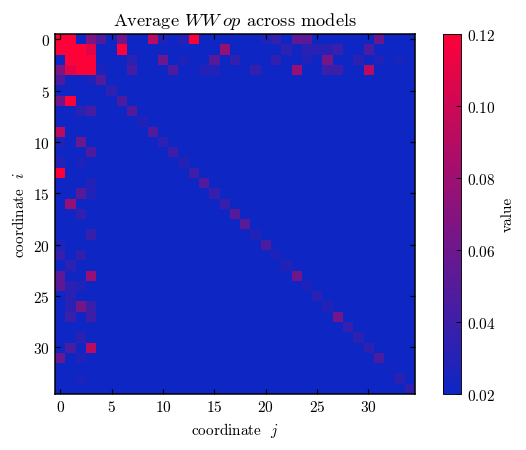

/tmp/ipykernel_1237622/2007969657.py:522: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


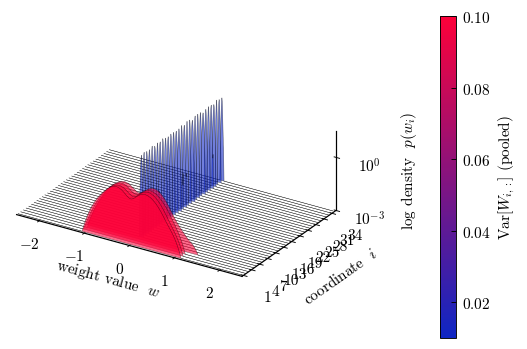

In [3]:
# === Multi-model average p(w_i) ridgeline + average WW^T heatmap ===
# Add this below your existing imports/helpers (keeps your theme + helpers)

# -------------------------------------------------------------------
# Utilities to load many models and sanity-check shapes
# -------------------------------------------------------------------

# === Styled 3D ridgeline for p(w_i) + WW^T heatmap (custom hex gradient, custom vmin/vmax, clean boxed look)
import os, sys, glob, math, time, json, random
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional, Any

import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator  # << for pretty log ticks

# -----------------------------------------------------------------------------
# Locate & import slim_plotters.py no matter if it's in plot_utils/ or plots_utils/
# -----------------------------------------------------------------------------

def import_slim_plotters():
    # Common places to try — add your custom absolute path(s) here if needed
    candidates = [
        "/home/goring/mean_field_langevin/plots_utils/",
        "plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]

    # 1) Try direct module path by adding the directory containing slim_plotters.py
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            try:
                import slim_plotters as sp  # noqa
                return sp
            except Exception as e:
                print(f"[note] Found in {d} but import failed: {e!r}")

    # 2) Try package-style imports (requires __init__.py in the folder)
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass

    raise ModuleNotFoundError(
        "Could not import slim_plotters. "
        "Make sure slim_plotters.py exists in one of: "
        + ", ".join(candidates)
        + " (or update the 'candidates' list above)."
    )

sp = import_slim_plotters()
apply, color, COLORS, CYCLE = sp.apply, sp.color, sp.COLORS, sp.CYCLE

# Apply your theme (switch to theme='dark' if you like)
apply(theme="light", serif=True)

# -----------------------------------------------------------------------------
# Small helpers for a clean, boxed look (no grey panes, no grids)
# -----------------------------------------------------------------------------

def style_axes_box(ax):
    """2D axes: white background, no grid, visible spines."""
    ax.set_facecolor("white")
    ax.grid(False)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color("black")
    ax.tick_params(axis="both", which="both", length=3, width=0.8, colors="black")


def style_3d_axes_box(ax):
    """3D axes: remove pane fills & grid; keep coordinate lines and box."""
    ax.set_facecolor("white")
    ax.grid(False)
    # Hide the grey panes
    try:
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
    except Exception:
        pass
    # Also kill gridlines via _axinfo (mplot3d internals)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        try:
            axis._axinfo["grid"]["linewidth"] = 0.0
            axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        except Exception:
            pass
        # Emphasize axis (coordinate) lines
        try:
            axis.line.set_color("black")
            axis.line.set_linewidth(0.8)
        except Exception:
            pass
    # Make the surrounding box lines a touch darker
    try:
        ax.w_xaxis.set_pane_color((1, 1, 1, 0))
        ax.w_yaxis.set_pane_color((1, 1, 1, 0))
        ax.w_zaxis.set_pane_color((1, 1, 1, 0))
    except Exception:
        pass

# -----------------------------------------------------------------------------
# Loading helpers (UPDATED to read particles saved by your training code)
# -----------------------------------------------------------------------------

def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]


def _load_W_list_from_particles_pt(pt_path: str, map_location="cpu") -> List[torch.Tensor]:
    """
    Load a particles snapshot saved by your training code's _save_particles().
    Returns a list of tensors [W_e^T] with shape (d, B) for each experiment e.
    Accepts either:
      pkg = {"params":{"W": (E,B,d), "a":..., "rho":...}, "stats":..., "meta":...}
    or a flat dict with "W".
    """
    pkg = torch.load(pt_path, map_location=map_location)
    if isinstance(pkg, dict) and "params" in pkg and isinstance(pkg["params"], dict) and "W" in pkg["params"]:
        W_EBD = pkg["params"]["W"]
    elif isinstance(pkg, dict) and "W" in pkg:
        W_EBD = pkg["W"]
    else:
        raise KeyError(f"{pt_path}: expected 'params[\"W\"]' or top-level 'W' in snapshot.")
    if W_EBD.ndim != 3:
        raise ValueError(f"{pt_path}: expected W shape (E,B,d), got {tuple(W_EBD.shape)}")
    E, B, d = W_EBD.shape
    # Convert per-experiment to shape (d, B) to match downstream plotting code
    return [W_EBD[e].detach().cpu().T.contiguous() for e in range(E)]


def _load_W_list_from_particles_npz(npz_path: str) -> List[torch.Tensor]:
    """
    Load the compressed NumPy snapshot saved alongside the .pt by _save_particles().
    """
    z = np.load(npz_path)
    if "W" not in z:
        raise KeyError(f"{npz_path}: missing 'W' array.")
    W = z["W"]  # (E,B,d)
    if W.ndim != 3:
        raise ValueError(f"{npz_path}: expected W shape (E,B,d), got {W.shape}")
    E, B, d = W.shape
    return [torch.from_numpy(W[e].T.copy()) for e in range(E)]  # (d,B)


def _resolve_snapshot_from_json(json_path: str) -> Optional[str]:
    """
    Given a training JSON (the big log file), pick the 'final' particles snapshot path if present,
    otherwise fall back to 'init'. Prefer the .pt snapshot; if missing, try the .npz.
    """
    with open(json_path, "r") as f:
        payload = json.load(f)
    snaps = payload.get("snapshots", {})
    final = snaps.get("final", {})
    init = snaps.get("init", {})
    for bucket in (final, init):
        if isinstance(bucket, dict):
            if bucket.get("pt"):
                return bucket["pt"]
            if bucket.get("npz"):
                return bucket["npz"]
    return None


def load_W_list_from_paths(paths: List[str], map_location="cpu") -> List[torch.Tensor]:
    """
    Accepts a list of paths where each path can be:
      - a particles .pt (preferred)   -> loads (E,B,d) and splits into E items
      - a particles .npz              -> loads (E,B,d) and splits into E items
      - a training .json log          -> resolves to snapshots.final/init and loads
    Returns a flat list of W matrices with shape (d, N_i) each (N_i = B per exp).
    """
    out: List[torch.Tensor] = []
    for p in paths:
        if not os.path.exists(p):
            raise FileNotFoundError(f"Path not found: {p}")
        ext = os.path.splitext(p)[1].lower()
        resolved = p
        if ext == ".json":
            resolved = _resolve_snapshot_from_json(p)
            if resolved is None:
                raise FileNotFoundError(f"{p}: could not find snapshot paths in JSON.")
            ext = os.path.splitext(resolved)[1].lower()
        if ext == ".pt":
            out.extend(_load_W_list_from_particles_pt(resolved, map_location=map_location))
        elif ext == ".npz":
            out.extend(_load_W_list_from_particles_npz(resolved))
        else:
            raise ValueError(f"Unsupported file extension for {p}. Use .pt, .npz, or .json.")
    # sanity: all must share the same d
    if not out:
        raise ValueError("No weights loaded.")
    d_ref = out[0].shape[0]
    for i, W in enumerate(out):
        if W.ndim != 2 or W.shape[0] != d_ref:
            raise ValueError(f"All W must be 2D with same d. Item {i} has shape {tuple(W.shape)} vs d={d_ref}.")
    return out  # [ (d x B_e) for each experiment e across all provided paths ]

# -------------------------------------------------------------------
# Average WW^T heatmap across models (clean, boxed, custom cmap+range)
# -------------------------------------------------------------------

def plot_avg_WWT_heatmap(
    W_list,
    cmap_stops_hex=None,
    vmin=None,
    vmax=None,
    title=r"Average $WW^	op$",
    annotate=False,
    savepath="plots/_WWT_avg.svg",
    figsize=(7.2, 6.4),
):
    """Average Gram (WW^T) across models and draw a boxed heatmap.

    New: pass `figsize=(width, height)` to control figure size.
    """
    # Average Gram matrices
    Gs = []
    for W in W_list:
        Wnp = W.numpy()
        Gs.append(Wnp @ Wnp.T)
    G = np.mean(Gs, axis=0)

    # custom cmap + robust vmin/vmax
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="heatmap")
    vmin_auto, vmax_auto = float(np.min(G)), float(np.max(G))
    vmin_use = vmin_auto if vmin is None else float(vmin)
    vmax_use = vmax_auto if vmax is None else float(vmax)
    if not np.isfinite(vmin_use):
        vmin_use = vmin_auto
    if not np.isfinite(vmax_use):
        vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12  # prevent mpl error if inverted

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(G, cmap=cmap, vmin=vmin_use, vmax=vmax_use, origin="upper")
    ax.set_title(title)
    ax.set_xlabel("coordinate  $j$")
    ax.set_ylabel("coordinate  $i$")
    style_axes_box(ax)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"value")

    if annotate and G.shape[0] <= 40:
        for i in range(G.shape[0]):
            for j in range(G.shape[1]):
                ax.text(j, i, f"{G[i, j]:.2f}", ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Multi-model ridgeline: average KDE per coordinate
#   avg_mode = 'mixture'  -> average per-model KDEs (true mean of dists)
#            = 'pool'     -> one KDE on concatenated samples across models
# variance_mode = 'pooled' (default), 'mean', or 'median' for colorbar
# -------------------------------------------------------------------

def linear_cmap_from_hex(stops_hex=None, name="custommap"):
    """
    Build a linear segmented colormap from a list of hex color stops.
    - stops_hex: list like ['#0066ff', '#ff3366'] or with a middle ['#0066ff','#8a3ffc','#ff3366'].
    """
    if stops_hex is None:
        # Default to original palette idea (blue → purple → red) via slim_plotters
        stops_hex = [color("blue"), color("purple"), color("red")]
    return LinearSegmentedColormap.from_list(name, stops_hex, N=256)

def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).reshape(-1)
    G = np.asarray(grid, dtype=np.float64).reshape(-1)
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if n == 1:
        bw = 1e-3 if bandwidth is None else float(bandwidth)
    else:
        if bandwidth is None:
            std = np.std(x, ddof=1)
            bw = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
        else:
            bw = float(bandwidth)
        bw = max(bw, 1e-12)
    z = (G[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * bw * math.sqrt(2.0 * math.pi))
    return dens


def plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=401,
    weight_range=None,
    bandwidth=None,          # if given, used for *all* KDEs
    normalize_rows=False,    # keep False to reflect absolute scale
    avg_mode="mixture",      # 'mixture' or 'pool'
    variance_mode="pooled",  # 'pooled'|'mean'|'median'
    model_weights=None,      # optional weights per model (mixture only)
    y_step=0.85,
    alpha=0.85,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=None,
    var_vmin=None,
    var_vmax=None,
    z_log=True,
    z_floor=1e-6,
    savepath="plots/_pw_avg.svg",
    # New knobs for making it FLATTER
    figsize=(10.5, 6.2),     # figure size (w, h)
    z_scale=1.0,             # compress vertical scale: e.g. 0.3 for much flatter
    box_aspect=None,         # e.g. (1, 1, 0.25) to squash z vs x/y
    ortho=True,              # use orthographic projection to reduce perspective
    # New: explicit log tick exponents (unscaled). Example: (0,3) -> show 10^0 and 10^3
    z_log_ticks=None,
):
    """3D ridgeline of average per-row densities across models.

    To make the plot flatter:
      - Lower `z_scale` (try 0.2–0.5).
      - Pass a smaller height in `figsize` (e.g., (10.5, 3.6)).
      - Set `box_aspect=(1, 1, 0.25)` (requires Matplotlib ≥3.3).
      - Reduce `y_step` to squeeze rows closer together.
      - Keep `ortho=True` to reduce perspective exaggeration.

    Ticks:
      - If `z_log=True` and `z_log_ticks` is provided (e.g., `(0, 3)`), the Z axis
        will only show those powers of 10.
    """
    # ---------- grid range ----------
    d = W_list[0].shape[0]
    if weight_range is None:
        abs_vals = np.concatenate([np.abs(W.numpy()).ravel() for W in W_list])
        if abs_vals.size:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.max() > 0 else 1.0))
        else:
            hi = 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # ---------- per-row densities + variance stats across models ----------
    dens_rows = []
    var_rows = []

    # weights for mixture averaging
    if avg_mode == "mixture":
        if model_weights is None:
            # default: proportional to per-model sample count for that row
            model_weights = np.array([W.shape[1] for W in W_list], dtype=float)
        mw = model_weights / np.sum(model_weights)
    else:
        mw = None

    for i in rows:
        # Collect samples for row i
        samples_list = [W[i, :].numpy() for W in W_list]
        Ns = [s.size for s in samples_list if s.size > 0]

        # ---- variance across models (colorbar stat) ----
        if variance_mode == "pooled":
            # variance on concatenated samples (unbiased, ddof=1)
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            v_stat = float(np.var(pooled, ddof=1)) if pooled.size > 1 else 0.0
        else:
            # per-model row variance, then mean/median
            per_model_vars = [float(np.var(s, ddof=1)) if s.size > 1 else 0.0 for s in samples_list]
            if variance_mode == "mean":
                v_stat = float(np.mean(per_model_vars)) if per_model_vars else 0.0
            elif variance_mode == "median":
                v_stat = float(np.median(per_model_vars)) if per_model_vars else 0.0
            else:
                raise ValueError("variance_mode must be 'pooled', 'mean', or 'median'")
        var_rows.append(v_stat)

        # ---- density per row (mixture average or pooled) ----
        if avg_mode == "pool":
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            di = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        elif avg_mode == "mixture":
            # average the per-model KDEs with weights mw (default ∝ sample size)
            parts = []
            for m, s in enumerate(samples_list):
                di_m = gaussian_kde_1d(s, grid, bandwidth=bandwidth)
                parts.append(mw[m] * di_m)
            di = np.sum(parts, axis=0) if parts else np.zeros_like(grid)
        else:
            raise ValueError("avg_mode must be 'mixture' or 'pool'")

        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m

        dens_rows.append(di)

    dens = np.asarray(dens_rows)         # shape: (#rows) x grid_points
    variances = np.asarray(var_rows)     # shape: (#rows,)

    # ---------- log transform BEFORE polygons ----------
    if z_log:
        dens = np.maximum(dens, z_floor)
        dens_plot = np.log10(dens)
        base_z = math.log10(z_floor)
        zlabel = r"log density  $p(w_i)$"
    else:
        dens_plot = dens
        base_z = 0.0
        zlabel = r"density  $p(w_i)$"

    # ---------- vertical compression (NEW) ----------
    z_scale = float(z_scale) if np.isfinite(z_scale) else 1.0
    dens_plot_scaled = base_z + (dens_plot - base_z) * z_scale

    # ---------- color by variance ----------
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="varmap_multi")
    vmin_auto, vmax_auto = float(np.min(variances)), float(np.max(variances))
    vmin_use = vmin_auto if var_vmin is None else float(var_vmin)
    vmax_use = vmax_auto if var_vmax is None else float(var_vmax)
    if not np.isfinite(vmin_use):
        vmin_use = vmin_auto
    if not np.isfinite(vmax_use):
        vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)

    verts, facecols = [], []
    for di_plot_scaled, v in zip(dens_plot_scaled, variances):
        poly = list(zip(grid, di_plot_scaled)) + [(grid[-1], base_z), (grid[0], base_z)]
        verts.append(poly)
        facecols.append(cmap(norm(v)))

    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection='3d')

    # Orthographic projection reduces perspective exaggeration (flatter look)
    try:
        ax.set_proj_type('ortho' if ortho else 'persp')
    except Exception:
        pass

    ys = np.arange(len(rows)) * y_step
    polycoll = PolyCollection(
        verts, facecolors=facecols, edgecolors="black", linewidths=0.3, alpha=alpha
    )
    ax.add_collection3d(polycoll, zs=ys, zdir='y')

    # limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5 if len(ys) else y_step)
    zmax = float(np.max(dens_plot_scaled)) if dens_plot_scaled.size else 1.0
    ax.set_zlim(base_z, zmax * 1.05)

    # pretty ticks if log plotting
    if z_log:
        if z_log_ticks is not None and len(z_log_ticks) > 0:
            # Map requested exponents (unscaled) to scaled Z positions
            tick_positions = [base_z + (float(E) - base_z) * max(z_scale, 1e-12) for E in z_log_ticks]
            ax.set_zticks(tick_positions)
            ax.set_zticklabels([rf"$10^{{{int(E)}}}$" for E in z_log_ticks])
        else:
            # Default: integer ticks with formatter that accounts for scaling
            ax.zaxis.set_major_locator(MaxNLocator(integer=True))
            def _log_tick_formatter(v, pos):
                inv = base_z + (v - base_z) / max(z_scale, 1e-12)  # inverse of scaling
                return rf"$10^{{{int(round(inv))}}}$"
            ax.zaxis.set_major_formatter(FuncFormatter(_log_tick_formatter))

    # labels/ticks
    ax.set_xlabel("weight value  $w$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_zlabel(zlabel)
    if len(rows):
        tick_every = max(1, len(rows)//10)
        tick_idx = np.arange(0, len(rows), tick_every)
        ax.set_yticks(ys[tick_idx])
        ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])
    ax.view_init(elev=elev, azim=azim)

    # variance colorbar
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.025)
    cbar.set_label(r"$\mathrm{Var}[W_{i,:}]$ (" + variance_mode + ")")

    # clean boxed look
    style_3d_axes_box(ax)

    # Optional: force a flatter 3D box aspect (requires Matplotlib ≥ 3.3)
    if box_aspect is not None:
        try:
            ax.set_box_aspect(box_aspect)
        except Exception:
            pass

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Example usage
# -------------------------------------------------------------------
# Provide one or more paths to your saved runs. Each path can be:
#   - the training JSON (we'll auto-resolve to snapshots.final/init),
#   - a '__final_particles.pt' (preferred), or
#   - a '__final_particles.npz' (also ok).
SNAPSHOT_FILES = [
  #"/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_3_fix/5e-3/rs_aw_ard_sgld_FAST_P2133_kap5.000e-03_Ptr2133_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt"
  "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_0.01_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt"
  ]

if not SNAPSHOT_FILES:
    # fallback: grab newest snapshot .pt/.npz/.json from a directory (edit as needed)
    MODEL_DIR = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_0.01_fix/5e-3"
    all_candidates = sorted(
        glob.glob(os.path.join(MODEL_DIR, "*__final_particles.pt"))
        + glob.glob(os.path.join(MODEL_DIR, "*__final_particles.npz"))
        + glob.glob(os.path.join(MODEL_DIR, "rs_aw_*.json")),
        key=os.path.getmtime
    )
    SNAPSHOT_FILES = all_candidates[-1:]  # last one by default

print("Loading from:", SNAPSHOT_FILES)
W_list = load_W_list_from_paths(SNAPSHOT_FILES, map_location="cpu")
print("Loaded #models (experiments):", len(W_list), " | each has shape like:", tuple(W_list[0].shape))

# ---- Customize colors/ranges as before ----
CMAP_STOPS = ["#0E26C4", "#FD0139"]     # or ["#0066ff", "#8a3ffc", "#ff3366"]

# Heatmap color range (optional). If you had vmin>vmax, we guard against it.
HEAT_VMIN = 0.02
HEAT_VMAX = 0.12

# Variance → color mapping for ridgeline (pooled across models by default)
VAR_VMIN = 0.01
VAR_VMAX = 0.10

# 1) Average WW^T heatmap across models (now with figsize)
_ = plot_avg_WWT_heatmap(
    W_list,
    cmap_stops_hex=CMAP_STOPS,
    vmin=HEAT_VMIN,
    vmax=HEAT_VMAX,
    title=r"Average $WW^	op$ across models",
    annotate=False,
    savepath="plots/_WWT_avg.svg",
    figsize=(7.2, 4.2),   # << shorter height => flatter
)

# 2) Multi-model ridgeline: average p(w_i) across models (E experiments)
_ = plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=1000,
    weight_range=(-2.5, 2.5),
    bandwidth=None,               # per-KDE Scott's rule (unless you set a fixed bw)
    normalize_rows=False,
    avg_mode="mixture",           # 'mixture' (mean of per-model densities) or 'pool'
    variance_mode="pooled",       # 'pooled'|'mean'|'median'
    model_weights=None,            # or e.g. weights ∝ N_i
    y_step=0.65,                   # << rows closer together
    alpha=0.59,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=CMAP_STOPS,
    var_vmin=VAR_VMIN,
    var_vmax=VAR_VMAX,
    z_log=True,
    z_floor=1e-3,
    savepath="plots/_pw_avg.svg",
    # NEW knobs to make it *much flatter*:
    figsize=(10.5, 3.8),   # << shorter figure height
    z_scale=0.30,          # << compress vertical scale strongly
    box_aspect=(1.5, 1, 0.5),  # << squash z relative to x/y
    ortho=True,
    # NEW: only show two Z ticks at 10^0 and 10^3
    z_log_ticks=(-3, 0),
)
